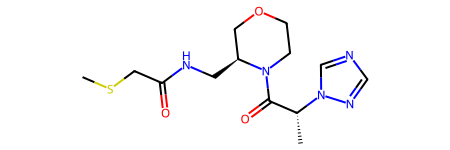

In [1]:
import os
import logging
import warnings

import numpy as np
import torch
from rdkit.Contrib.LEF.ClusterFps import sim

# 屏蔽干扰信息
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
logging.getLogger().setLevel(logging.ERROR)
warnings.filterwarnings("ignore")


'''mol==molecule'''


# all imports
from deepchem.molnet.load_function.zinc15_datasets import load_zinc15
from deepchem.feat.molecule_featurizers.raw_featurizer import RawFeaturizer
from deepchem.feat.molecule_featurizers.smiles_to_image import SmilesToImage  # this featurizer converts smiles string to image
from deepchem.data.datasets import Dataset
from rdkit import Chem
import matplotlib.pyplot as plt
import networkx as nx

raw_feat=RawFeaturizer()
zinc15_raw_data=load_zinc15(featurizer=raw_feat)




'''从数据集中提取信息'''
def get_training_data(dataset:Dataset,verbose=1):

    tasks,datasets,transformer=dataset
    print("tasks",tasks) if verbose else None
    training_data,valid_data,testing_data=datasets
    # if verbose:
    #     print("training_data",training_data)
    #     print("valid_data",valid_data)
    #     print("testing_data",testing_data)
    #     print("transformer",transformer)
    return training_data


def data_verbose(dataset:Dataset,verbose=1):
    traning_data=get_training_data(dataset,verbose)
    one_mol=None
    for (xi,yi,wi,idi) in traning_data.itersamples():
        one_mol=xi=xi
        if verbose:
            print("Molecule Object >>", xi)
            print("Task Target Value>>", yi)  # the target label for the dataset
            print("Weight >>", wi)  # weight associated
            print("ZINC ID>>", idi)  # zinc id for the molecule
        return one_mol
# print(data_verbose(zinc15_raw_data))
# # traning_data = get_training_data(zinc15_raw_data)
# # print(type(traning_data))    output:<class 'deepchem.data.datasets.DiskDataset'>


'''Monomer Molecules Representation-use RDkit'''
first_molecule=data_verbose(zinc15_raw_data)
print(first_molecule.GetNumAtoms(),end=' ')
print(first_molecule.GetNumBonds(),end=' ')
first_molecule


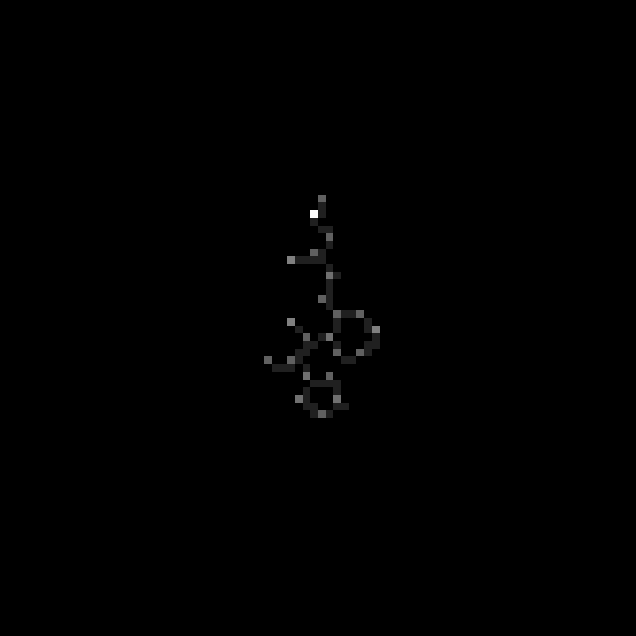

In [3]:
'''use image'''
def image_verbose(dataset:Dataset,verbose=1):
    training_data=get_training_data(dataset,verbose=verbose)
    smiles2img_feat=SmilesToImage(img_size=80)
    img=None
    for (xi,yi,wi,idi) in training_data.itersamples():
        if verbose:
            print("x0 >>",xi)
            print("y0 >>",yi)
            print("w0 >>",wi)
            print("id0 >>",idi)
        img=smiles2img_feat._featurize(xi)
        plt.figure(figsize=(8,8))
        plt.imshow(img,cmap='gray')
        plt.axis('off')
        plt.show()
        return img
img_array = image_verbose(zinc15_raw_data, verbose=0)

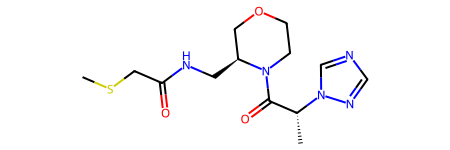

In [4]:
image_feat=SmilesToImage(img_size=80,img_spec='std')
zinc15_raw_data=load_zinc15(featurizer=raw_feat)
data_verbose(zinc15_raw_data)

In [11]:
def rdkit_image_verbose(dataset:Dataset,verbose=1):
    training_data=get_training_data(dataset,verbose=verbose)
    img=None
    for (xi,yi,wi,idi) in training_data.itersamples:
        if verbose:
          print("y0 >>",yi)
          print("w0 >>",wi)
          print("id0 >>",idi)
        img = Chem.Draw.MolToImage(xi)   # getting the image array from molecule
        plt.figure(figsize=(8,8))
        plt.imshow(img, cmap="gray")
        plt.axis('off')
        plt.show()
        return img

In [12]:
def mol_to_nx(mol):
  G = nx.Graph() # initiate the graph object

  for atom in mol.GetAtoms(): # iterating through atoms
      G.add_node(atom.GetIdx(),
                atomic_num=atom.GetAtomicNum(),
                is_aromatic=atom.GetIsAromatic(),
                atom_symbol=atom.GetSymbol())  # assigning nodes representing atoms

  for bond in mol.GetBonds(): # iterating through bonds
      G.add_edge(bond.GetBeginAtomIdx(),
                bond.GetEndAtomIdx(),
                bond_type=bond.GetBondType()) # assigning edges representing bonds

  return G # returning final graph

In [10]:


# utility function
def draw_graph(graph, figsize=(6,6)):
  atoms = nx.get_node_attributes(graph, 'atom_symbol')  # getting symbol or characters for each atom

  color_map = {'C': 'cyan',
              'O': 'orange',
              'N': 'magenta',
               "Cl": "pink"}  # map color to special symbol or character

  colors = []
  for idx in graph.nodes():
      if (graph.nodes[idx]['atom_symbol'] in color_map):
        colors.append(color_map[graph.nodes[idx]['atom_symbol']])   # assign colors to the list by using the color map
      else:
        colors.append('gray') # if the symbol is not in the color map assigning gray

  plt.figure(figsize=figsize)
  nx.draw(graph,
          labels=atoms,
          with_labels = True,
          node_color=colors,
          node_size=800)  # drawing the graph

  plt.show()



In [9]:


# utility function
def networkx_graph_verbose(dataset: Dataset, verbose=1):
  for xi,_,_,_ in dataset[1][0].itersamples():
    repr = xi
    # conver rdkit molecule object to networkx object
    repr_nx = mol_to_nx(repr)  # getting the graph object for
    if verbose:
      print(repr_nx)
    draw_graph(repr_nx)
    return repr_nx



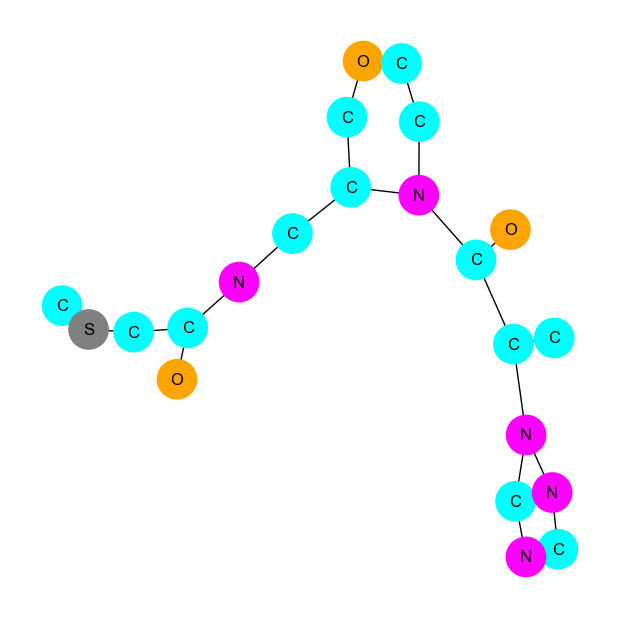

In [13]:
graph_repr = networkx_graph_verbose(zinc15_raw_data)